In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "/Users/alex/Downloads/esa-adb-challenge (1)"
train = pd.read_parquet(f"{DATA_DIR}/train.parquet")
test  = pd.read_parquet(f"{DATA_DIR}/test.parquet")

CHANNELS = [f"channel_{i}" for i in range(41, 47)]

# 1. Anomaly rate
print(train["is_anomaly"].value_counts(normalize=True))

# 2. Plot all 6 channels — full train, color anomalies red
fig, axes = plt.subplots(6, 1, figsize=(18, 12), sharex=True)
for i, (ax, ch) in enumerate(zip(axes, CHANNELS)):
    ax.plot(train[ch].values, lw=0.4, color="steelblue")
    ax.fill_between(range(len(train)), train[ch].min(), train[ch].max(),
                    where=(train["is_anomaly"]==1), alpha=0.4, color="red")
    ax.set_ylabel(ch, fontsize=8)
plt.suptitle("Train — all channels (red = anomaly)")
plt.savefig(f"{DATA_DIR}/eda_train_channels.png", dpi=150)
plt.close()

# 3. Zoom into an anomaly region
anomaly_indices = np.where(train["is_anomaly"].values == 1)[0]
print(f"\nAnomaly regions: first index {anomaly_indices[0]}, last {anomaly_indices[-1]}")
print(f"Total anomalous timesteps: {len(anomaly_indices):,}")

# 4. Channel correlations
print("\nCorrelation matrix (normal data only):")
normal = train[train["is_anomaly"]==0][CHANNELS]
print(normal.corr().round(2))

# 5. Compare train vs test distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, (ax, ch) in enumerate(zip(axes.flat, CHANNELS)):
    ax.hist(train[ch].values, bins=80, alpha=0.5, label="train", density=True)
    ax.hist(test[ch].values,  bins=80, alpha=0.5, label="test",  density=True)
    ax.set_title(ch, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Train vs Test distribution per channel")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/eda_distributions.png", dpi=150)
plt.close()

is_anomaly
0    0.895161
1    0.104839
Name: proportion, dtype: float64

Anomaly regions: first index 115383, last 14654252
Total anomalous timesteps: 1,544,104

Correlation matrix (normal data only):
            channel_41  channel_42  channel_43  channel_44  channel_45  \
channel_41        1.00       -0.45       -0.21        0.91       -0.26   
channel_42       -0.45        1.00       -0.08       -0.36        0.89   
channel_43       -0.21       -0.08        1.00       -0.33       -0.19   
channel_44        0.91       -0.36       -0.33        1.00       -0.17   
channel_45       -0.26        0.89       -0.19       -0.17        1.00   
channel_46       -0.13       -0.29        0.88       -0.25       -0.41   

            channel_46  
channel_41       -0.13  
channel_42       -0.29  
channel_43        0.88  
channel_44       -0.25  
channel_45       -0.41  
channel_46        1.00  


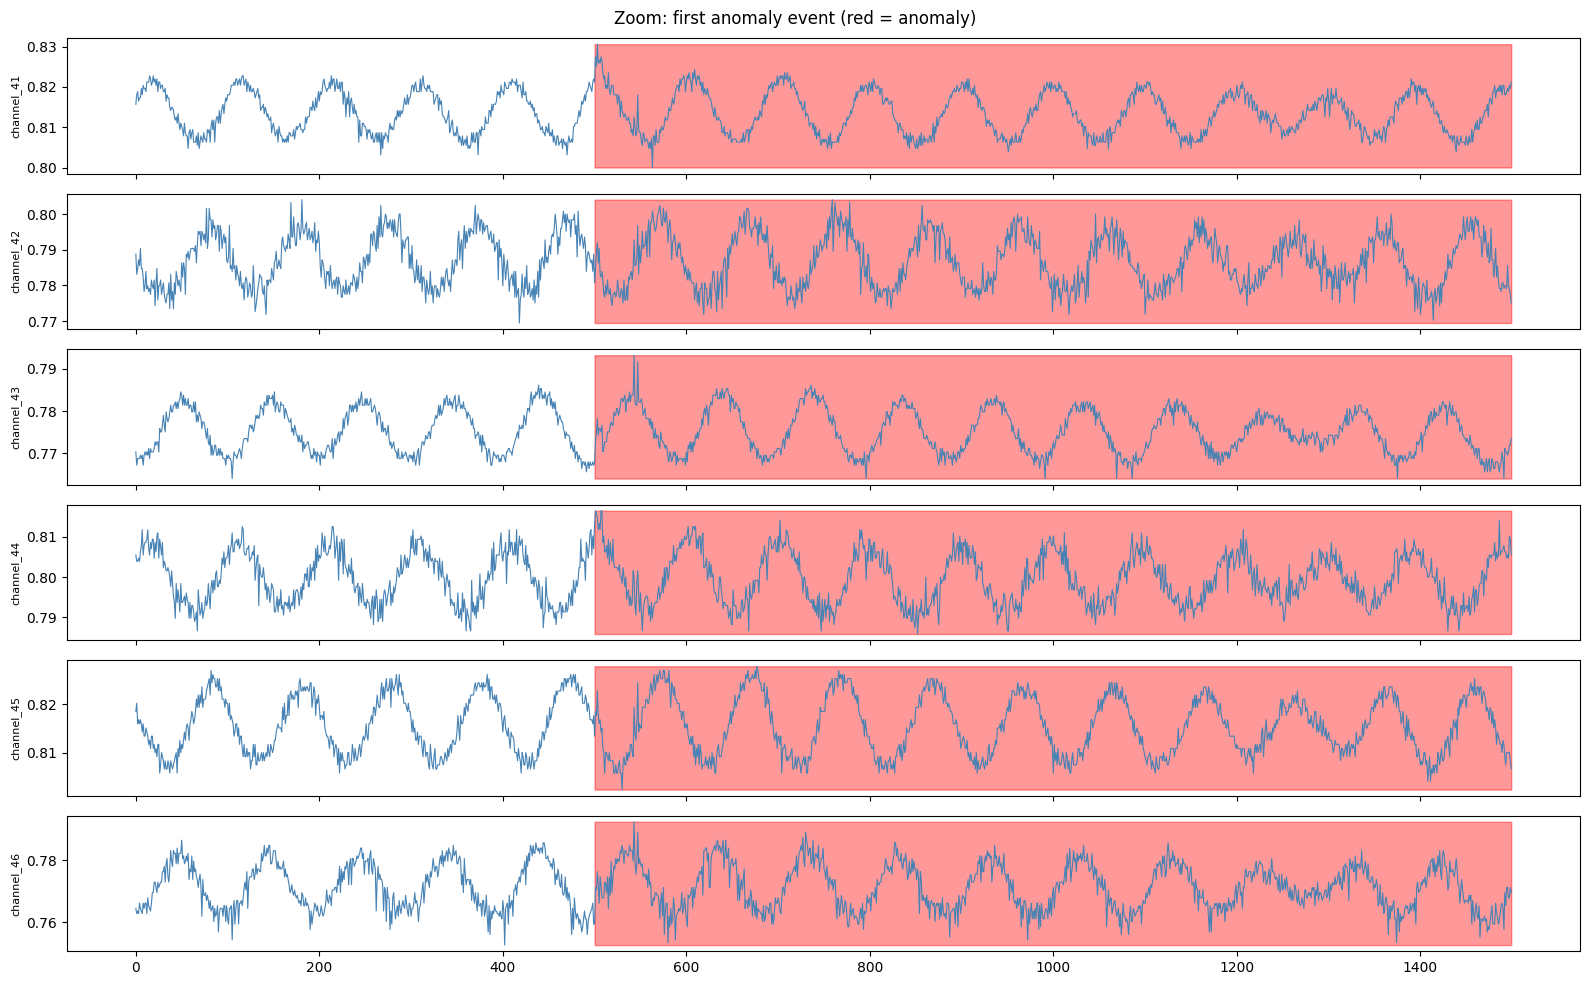

In [3]:
# Find a clean anomaly window and zoom in
anom_idx = np.where(train["is_anomaly"].values == 1)[0]
# Take the first anomaly event
first_anom = anom_idx[0]
window = slice(max(0, first_anom - 500), first_anom + 1000)

fig, axes = plt.subplots(6, 1, figsize=(16, 10), sharex=True)
x = np.arange(window.stop - window.start)
for i, (ax, ch) in enumerate(zip(axes, CHANNELS)):
    ax.plot(x, train[ch].values[window], lw=0.8, color="steelblue")
    ax.fill_between(x, train[ch].values[window].min(),
                       train[ch].values[window].max(),
                    where=(train["is_anomaly"].values[window]==1),
                    alpha=0.4, color="red")
    ax.set_ylabel(ch, fontsize=8)
plt.suptitle("Zoom: first anomaly event (red = anomaly)")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/eda_zoom_anomaly.png", dpi=150)
plt.show()

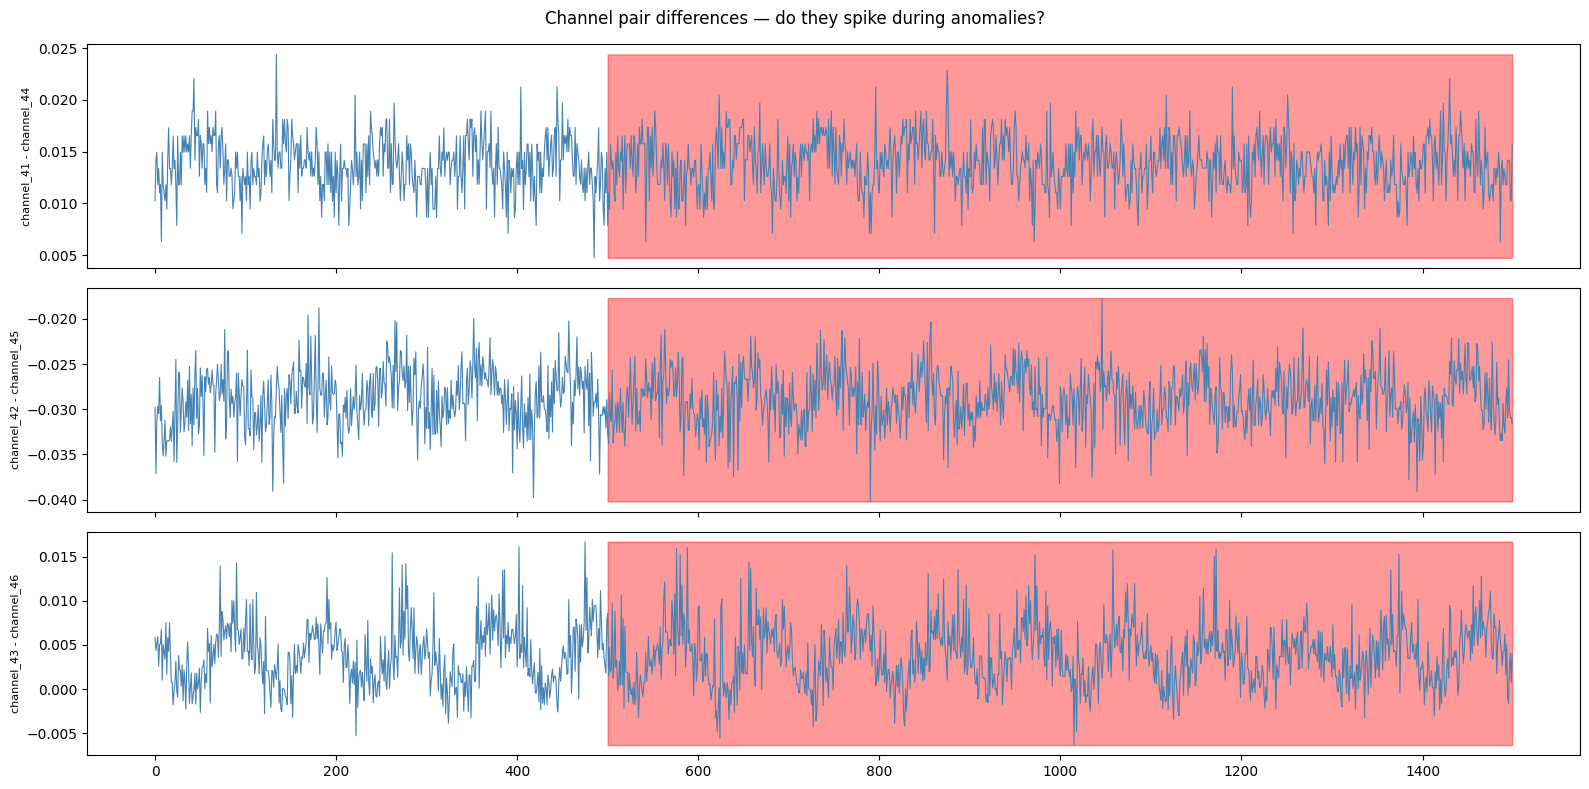

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
pairs = [("channel_41","channel_44"), ("channel_42","channel_45"), ("channel_43","channel_46")]
for ax, (c1, c2) in zip(axes, pairs):
    diff = train[c1].values[window] - train[c2].values[window]
    ax.plot(x, diff, lw=0.8, color="steelblue")
    ax.fill_between(x, diff.min(), diff.max(),
                    where=(train["is_anomaly"].values[window]==1),
                    alpha=0.4, color="red")
    ax.set_ylabel(f"{c1} - {c2}", fontsize=8)
plt.suptitle("Channel pair differences — do they spike during anomalies?")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/eda_pair_diffs.png", dpi=150)
plt.show()

=== MEAN ===
Normal : [0.80979 0.78369 0.77029 0.79596 0.81196 0.76715]
Anomaly: [0.79471 0.76877 0.75391 0.7774  0.79686 0.75255]

=== STD (variance) ===
Normal : [0.0052  0.00708 0.00547 0.00611 0.00583 0.0071 ]
Anomaly: [0.09399 0.09254 0.09611 0.10409 0.09452 0.091  ]

=== MIN ===
Normal : [0.79374 0.75743 0.75133 0.77241 0.79227 0.73912]
Anomaly: [0. 0. 0. 0. 0. 0.]

=== MAX ===
Normal : [0.82514 0.81044 0.78614 0.8165  0.82957 0.79316]
Anomaly: [0.98211 0.96627 0.95073 0.97551 1.      0.95953]


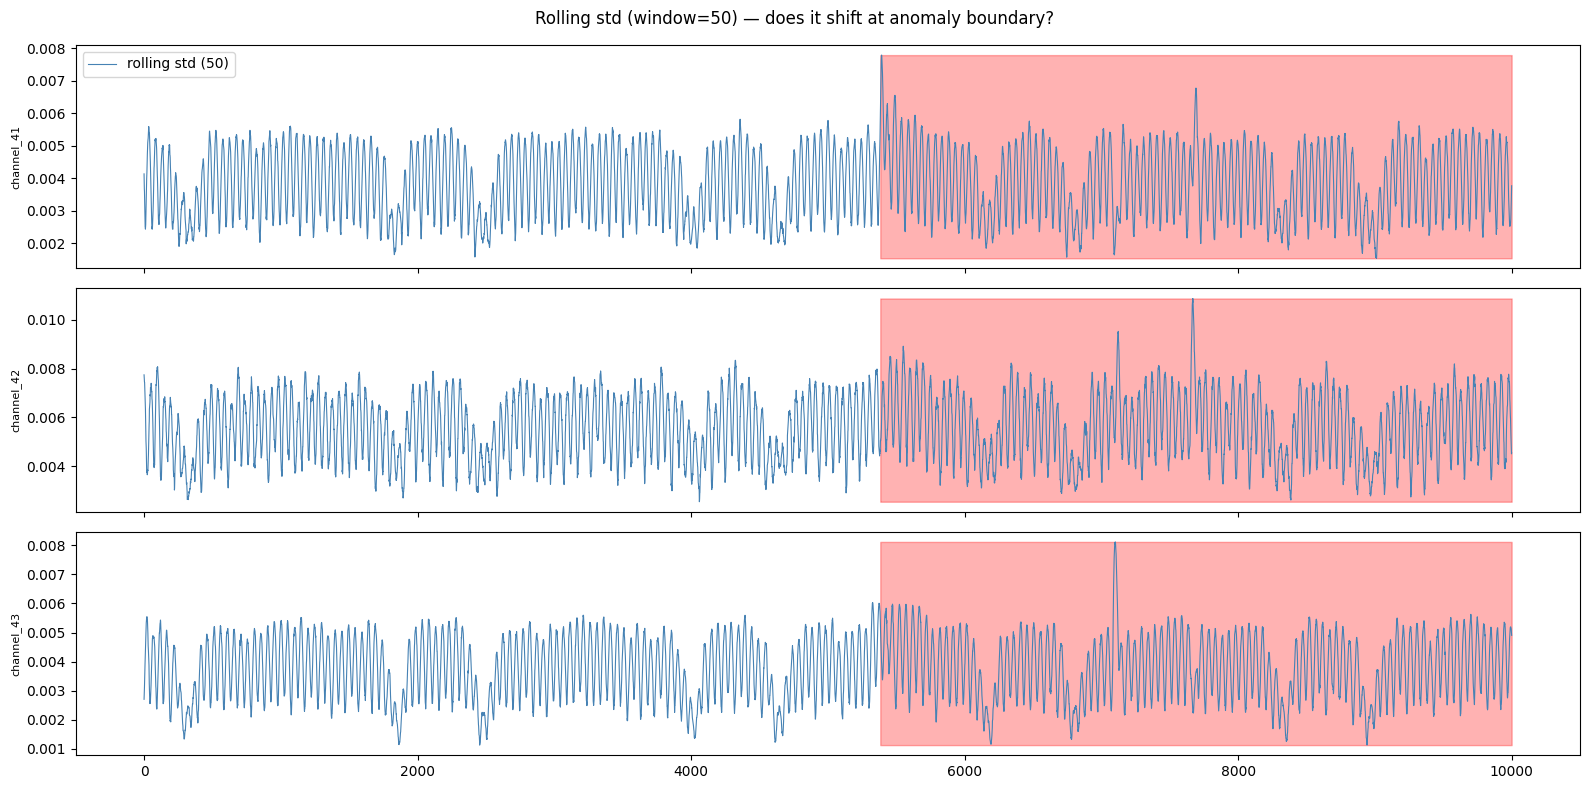

In [6]:
# Is the anomaly region statistically different?
CHANNELS = [f"channel_{i}" for i in range(41, 47)]

normal = train[train["is_anomaly"] == 0][CHANNELS]
anomal = train[train["is_anomaly"] == 1][CHANNELS]

print("=== MEAN ===")
print(f"Normal : {normal.mean().round(5).values}")
print(f"Anomaly: {anomal.mean().round(5).values}")

print("\n=== STD (variance) ===")
print(f"Normal : {normal.std().round(5).values}")
print(f"Anomaly: {anomal.std().round(5).values}")

print("\n=== MIN ===")
print(f"Normal : {normal.min().round(5).values}")
print(f"Anomaly: {anomal.min().round(5).values}")

print("\n=== MAX ===")
print(f"Normal : {normal.max().round(5).values}")
print(f"Anomaly: {anomal.max().round(5).values}")

# Rolling std — does it change at anomaly boundary?
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
window = slice(110_000, 120_000)  # straddles the first anomaly
for ax, ch in zip(axes, ["channel_41", "channel_42", "channel_43"]):
    rolling_std = train[ch].rolling(50).std()
    ax.plot(rolling_std.values[window], lw=0.8, color="steelblue", label="rolling std (50)")
    ax.fill_between(range(window.stop - window.start),
                    rolling_std.values[window].min(),
                    rolling_std.values[window].max(),
                    where=(train["is_anomaly"].values[window] == 1),
                    alpha=0.3, color="red")
    ax.set_ylabel(ch, fontsize=8)
axes[0].legend()
plt.suptitle("Rolling std (window=50) — does it shift at anomaly boundary?")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/eda_rolling_std.png", dpi=150)
plt.show()

In [7]:
"""
ESA Spacecraft Anomaly Detection — Rolling Std Detector
========================================================
Kaggle competition : esa-adb-challenge
Metric             : corrected event-wise F0.5  (precision >> recall)

Key insight from EDA:
    Normal  STD ~ 0.006  (signals oscillate in a tight band ~0.03 wide)
    Anomaly STD ~ 0.095  (signals explode to nearly full 0–1 range)
    → 18x variance increase. Rolling std is the perfect detector.

This runs in seconds, no GPU needed.

Usage:
    python esa_rolling_std.py

Outputs (same folder as data):
    submission_best.parquet   ← upload this to Kaggle
    rolling_std_signal.png
    threshold_search.png
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import binary_closing

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
DATA_DIR  = "/Users/alex/Downloads/esa-adb-challenge (1)"
CHANNELS  = [f"channel_{i}" for i in range(41, 47)]

# Rolling window for std computation
# Normal oscillation period looks ~50–80 timesteps from the plot.
# Use a window that captures ~1 full oscillation.
ROLL_WINDOW = 50

# Post-processing
MIN_EVENT_LEN = 20    # kill runs shorter than this (reduces false alarms)
CLOSE_GAP     = 10    # merge events separated by less than this


# ══════════════════════════════════════════════════════════════════════════════
# 1.  LOAD
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("ESA Rolling-Std Anomaly Detector")
print("=" * 60)

print("\n[1/6] Loading data ...")
train = pd.read_parquet(f"{DATA_DIR}/train.parquet")
test  = pd.read_parquet(f"{DATA_DIR}/test.parquet")
print(f"      Train : {train.shape}   Test : {test.shape}")


# ══════════════════════════════════════════════════════════════════════════════
# 2.  COMPUTE ROLLING STD SCORE
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n[2/6] Computing rolling std (window={ROLL_WINDOW}) ...")

def rolling_std_score(df, channels, window):
    """
    For each channel, compute rolling std.
    Final score = mean rolling std across all channels.
    Higher score = more variance = more likely anomalous.
    """
    stds = pd.DataFrame({
        ch: df[ch].rolling(window, center=True, min_periods=1).std()
        for ch in channels
    })
    # mean across channels — anomalies affect all channels simultaneously
    return stds.mean(axis=1).values.astype(np.float32)

train_scores = rolling_std_score(train, CHANNELS, ROLL_WINDOW)
test_scores  = rolling_std_score(test,  CHANNELS, ROLL_WINDOW)

# Separate normal scores from anomaly scores (train only, for threshold)
normal_mask    = train["is_anomaly"].values == 0
normal_scores  = train_scores[normal_mask]
anomaly_scores = train_scores[~normal_mask]

print(f"      Normal  score — mean: {normal_scores.mean():.5f}  "
      f"std: {normal_scores.std():.5f}  "
      f"p99: {np.percentile(normal_scores, 99):.5f}")
print(f"      Anomaly score — mean: {anomaly_scores.mean():.5f}  "
      f"std: {anomaly_scores.std():.5f}  "
      f"p01: {np.percentile(anomaly_scores, 1):.5f}")


# ══════════════════════════════════════════════════════════════════════════════
# 3.  FIND THRESHOLD ON TRAIN SET
# ══════════════════════════════════════════════════════════════════════════════

print("\n[3/6] Finding optimal threshold ...")

def get_events(labels):
    """Return list of (start, end) for each contiguous run of 1s."""
    events, in_event = [], False
    for i, v in enumerate(labels):
        if v == 1 and not in_event:
            start, in_event = i, True
        elif v == 0 and in_event:
            events.append((start, i - 1))
            in_event = False
    if in_event:
        events.append((start, len(labels) - 1))
    return events

def event_wise_f05(y_true, y_pred):
    """Corrected event-wise F0.5 — same as Kaggle metric."""
    true_events = get_events(y_true)
    pred_events = get_events(y_pred)
    if not pred_events or not true_events:
        return 0.0
    tp_pred = sum(
        1 for ps, pe in pred_events
        if any(ps <= te and pe >= ts for ts, te in true_events)
    )
    tp_true = sum(
        1 for ts, te in true_events
        if any(ps <= te and pe >= ts for ps, pe in pred_events)
    )
    precision = tp_pred / len(pred_events)
    recall    = tp_true / len(true_events)
    if precision + recall == 0:
        return 0.0
    return (1 + 0.25) * precision * recall / (0.25 * precision + recall)

def remove_short_events(labels, min_len):
    """Kill contiguous anomaly runs shorter than min_len."""
    result = labels.copy()
    i = 0
    while i < len(result):
        if result[i] == 1:
            j = i
            while j < len(result) and result[j] == 1:
                j += 1
            if (j - i) < min_len:
                result[i:j] = 0
            i = j
        else:
            i += 1
    return result

def postprocess(raw, close_gap, min_len):
    closed = binary_closing(raw, structure=np.ones(close_gap)).astype(int)
    return remove_short_events(closed, min_len)

# Grid search threshold on TRAINING set
# Use the gap between normal p99 and anomaly p01 as search range
low  = np.percentile(normal_scores,  95)
high = np.percentile(anomaly_scores,  5)
print(f"      Search range: [{low:.5f}, {high:.5f}]")

y_true = train["is_anomaly"].values.astype(int)
thresholds = np.linspace(low, high, 40)

results = []
for t in thresholds:
    raw   = (train_scores > t).astype(int)
    preds = postprocess(raw, CLOSE_GAP, MIN_EVENT_LEN)
    f05   = event_wise_f05(y_true, preds)
    rate  = preds.mean() * 100
    results.append({"threshold": t, "f05": f05, "rate": rate})

results_df = pd.DataFrame(results).sort_values("f05", ascending=False)
best       = results_df.iloc[0]
best_threshold = best["threshold"]

print(f"\n      Best threshold : {best_threshold:.5f}")
print(f"      Best F0.5      : {best['f05']:.4f}")
print(f"      Anomaly rate   : {best['rate']:.2f}%")
print(f"\n      Top 5 threshold configs:")
print(results_df.head().to_string(index=False))

# Threshold search plot
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(results_df["threshold"], results_df["f05"],  color="steelblue", label="F0.5")
ax2.plot(results_df["threshold"], results_df["rate"], color="tomato",    label="Anomaly %", linestyle="--")
ax1.axvline(best_threshold, color="black", linestyle=":", label=f"Best = {best_threshold:.4f}")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("F0.5", color="steelblue")
ax2.set_ylabel("Anomaly rate (%)", color="tomato")
ax1.set_title("Threshold Search on Train Set")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/threshold_search.png", dpi=150)
print(f"\n      Saved → threshold_search.png")
plt.close()


# ══════════════════════════════════════════════════════════════════════════════
# 4.  VALIDATE ON TRAIN  (sanity check)
# ══════════════════════════════════════════════════════════════════════════════

print("\n[4/6] Validating on train set ...")

raw_train   = (train_scores > best_threshold).astype(int)
pred_train  = postprocess(raw_train, CLOSE_GAP, MIN_EVENT_LEN)
train_f05   = event_wise_f05(y_true, pred_train)

print(f"      Train F0.5     : {train_f05:.4f}")
print(f"      Flagged        : {pred_train.sum():,} / {len(pred_train):,}  "
      f"({pred_train.mean()*100:.2f}%)")
print(f"      True anomalies : {y_true.sum():,} / {len(y_true):,}  "
      f"({y_true.mean()*100:.2f}%)")


# ══════════════════════════════════════════════════════════════════════════════
# 5.  SCORE + PLOT TEST SET
# ══════════════════════════════════════════════════════════════════════════════

print("\n[5/6] Scoring test set ...")

raw_test  = (test_scores > best_threshold).astype(int)
pred_test = postprocess(raw_test, CLOSE_GAP, MIN_EVENT_LEN)

print(f"      Flagged : {pred_test.sum():,} / {len(pred_test):,}  "
      f"({pred_test.mean()*100:.2f}%)")

# Rolling std signal plot (first 15k timesteps of test)
n_plot = min(15_000, len(test))
t      = np.arange(n_plot)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# Top: rolling std score vs threshold
axes[0].plot(t, test_scores[:n_plot], lw=0.7, color="steelblue", label="Rolling std score")
axes[0].axhline(best_threshold, color="red", linestyle="--",
                label=f"Threshold = {best_threshold:.4f}")
axes[0].fill_between(t, 0, test_scores[:n_plot].max(),
                     where=(pred_test[:n_plot] == 1),
                     alpha=0.2, color="red")
axes[0].set_ylabel("Rolling Std Score")
axes[0].legend(fontsize=8)
axes[0].set_title("Test Set — Rolling Std Score & Predictions")

# Middle: raw channel signal
for ch in CHANNELS:
    axes[1].plot(t, test[ch].values[:n_plot], lw=0.5, alpha=0.6)
axes[1].fill_between(t, test[CHANNELS].values[:n_plot].min(),
                        test[CHANNELS].values[:n_plot].max(),
                     where=(pred_test[:n_plot] == 1),
                     alpha=0.2, color="red", label="Anomaly")
axes[1].set_ylabel("Channel values")
axes[1].legend(fontsize=8)

# Bottom: prediction flags
axes[2].fill_between(t, 0, 1, where=(pred_test[:n_plot] == 1),
                     color="red", alpha=0.7, label="Predicted anomaly")
axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel("Anomaly flag")
axes[2].set_xlabel("Timestep")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/rolling_std_signal.png", dpi=150)
print(f"      Saved → rolling_std_signal.png")
plt.close()


# ══════════════════════════════════════════════════════════════════════════════
# 6.  SUBMISSION
# ══════════════════════════════════════════════════════════════════════════════

print("\n[6/6] Saving submission ...")

id_col = "id" if "id" in test.columns else None
sub = pd.DataFrame({
    "id":           test[id_col].values if id_col else np.arange(len(test)),
    "anomaly_flag": pred_test.astype(int),
})
out_path = f"{DATA_DIR}/submission_best.parquet"
sub.to_parquet(out_path, index=False)
print(f"      Saved → {out_path}")


# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)
print(f"\nMethod         : Rolling Std  (window={ROLL_WINDOW})")
print(f"Best threshold : {best_threshold:.5f}")
print(f"Train F0.5     : {train_f05:.4f}")
print(f"Test flagged   : {pred_test.sum():,}  ({pred_test.mean()*100:.2f}%)")
print(f"\nUpload to Kaggle: submission_best.parquet")
print("\nIf F0.5 on Kaggle is low:")
print("  → Increase ROLL_WINDOW (try 100, 200) for smoother signal")
print("  → Increase MIN_EVENT_LEN (try 50, 100) to reduce false alarms")
print("  → Check rolling_std_signal.png for visual confirmation")

ESA Rolling-Std Anomaly Detector

[1/6] Loading data ...
      Train : (14728321, 89)   Test : (521280, 88)

[2/6] Computing rolling std (window=50) ...
      Normal  score — mean: 0.00453  std: 0.00079  p99: 0.00526
      Anomaly score — mean: 0.00552  std: 0.00605  p01: 0.00205

[3/6] Finding optimal threshold ...
      Search range: [0.00511, 0.00343]

      Best threshold : 0.00511
      Best F0.5      : 0.1583
      Anomaly rate   : 5.01%

      Top 5 threshold configs:
 threshold      f05      rate
  0.005109 0.158337  5.012228
  0.005066 0.141421  7.435220
  0.005023 0.132253 11.059855
  0.004635 0.127577 60.945996
  0.004721 0.127554 52.427965

      Saved → threshold_search.png

[4/6] Validating on train set ...
      Train F0.5     : 0.1583
      Flagged        : 738,217 / 14,728,321  (5.01%)
      True anomalies : 1,544,104 / 14,728,321  (10.48%)

[5/6] Scoring test set ...
      Flagged : 15,578 / 521,280  (2.99%)
      Saved → rolling_std_signal.png

[6/6] Saving submissio

=== Fraction of timesteps with values < 0.01 (near zero / clipped) ===
Normal  : 0.0000%
Anomaly : 1.3807%

=== Fraction of timesteps with values > 0.95 (near max / clipped) ===
Normal  : 0.0000%
Anomaly : 0.7598%


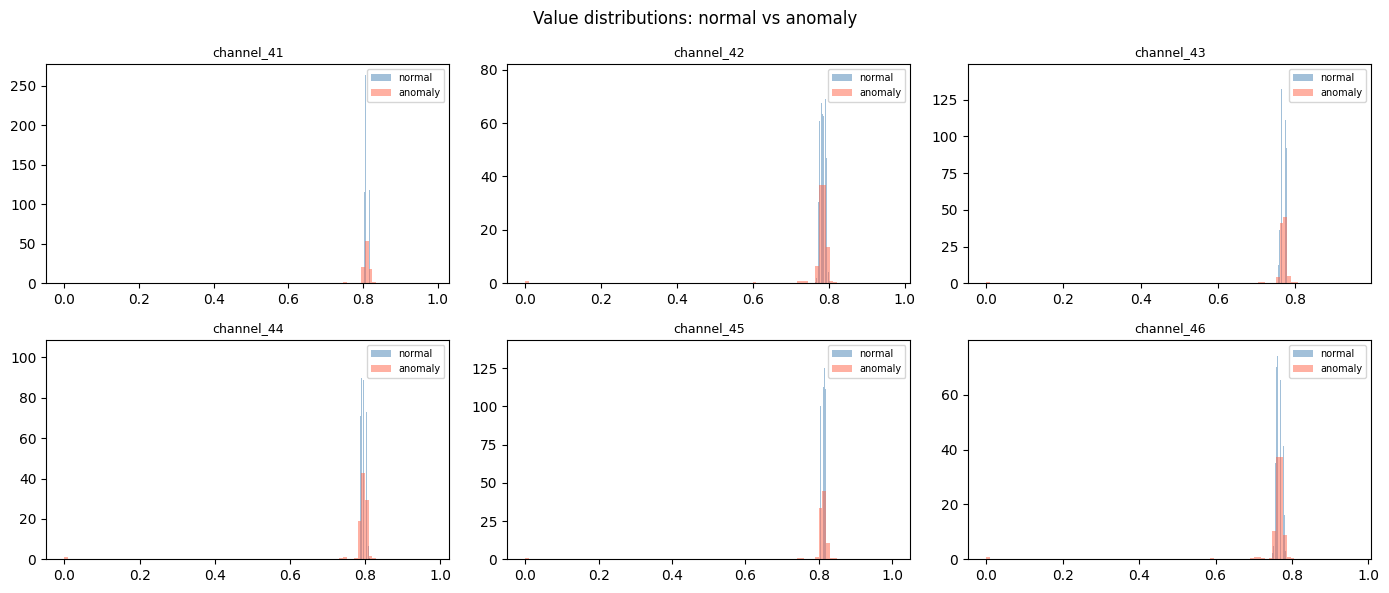


Number of anomaly events (0→1 transitions): 190
First 10 transition points: [115382 161603 165174 194564 225360 327271 339468 429015 437160 489939]


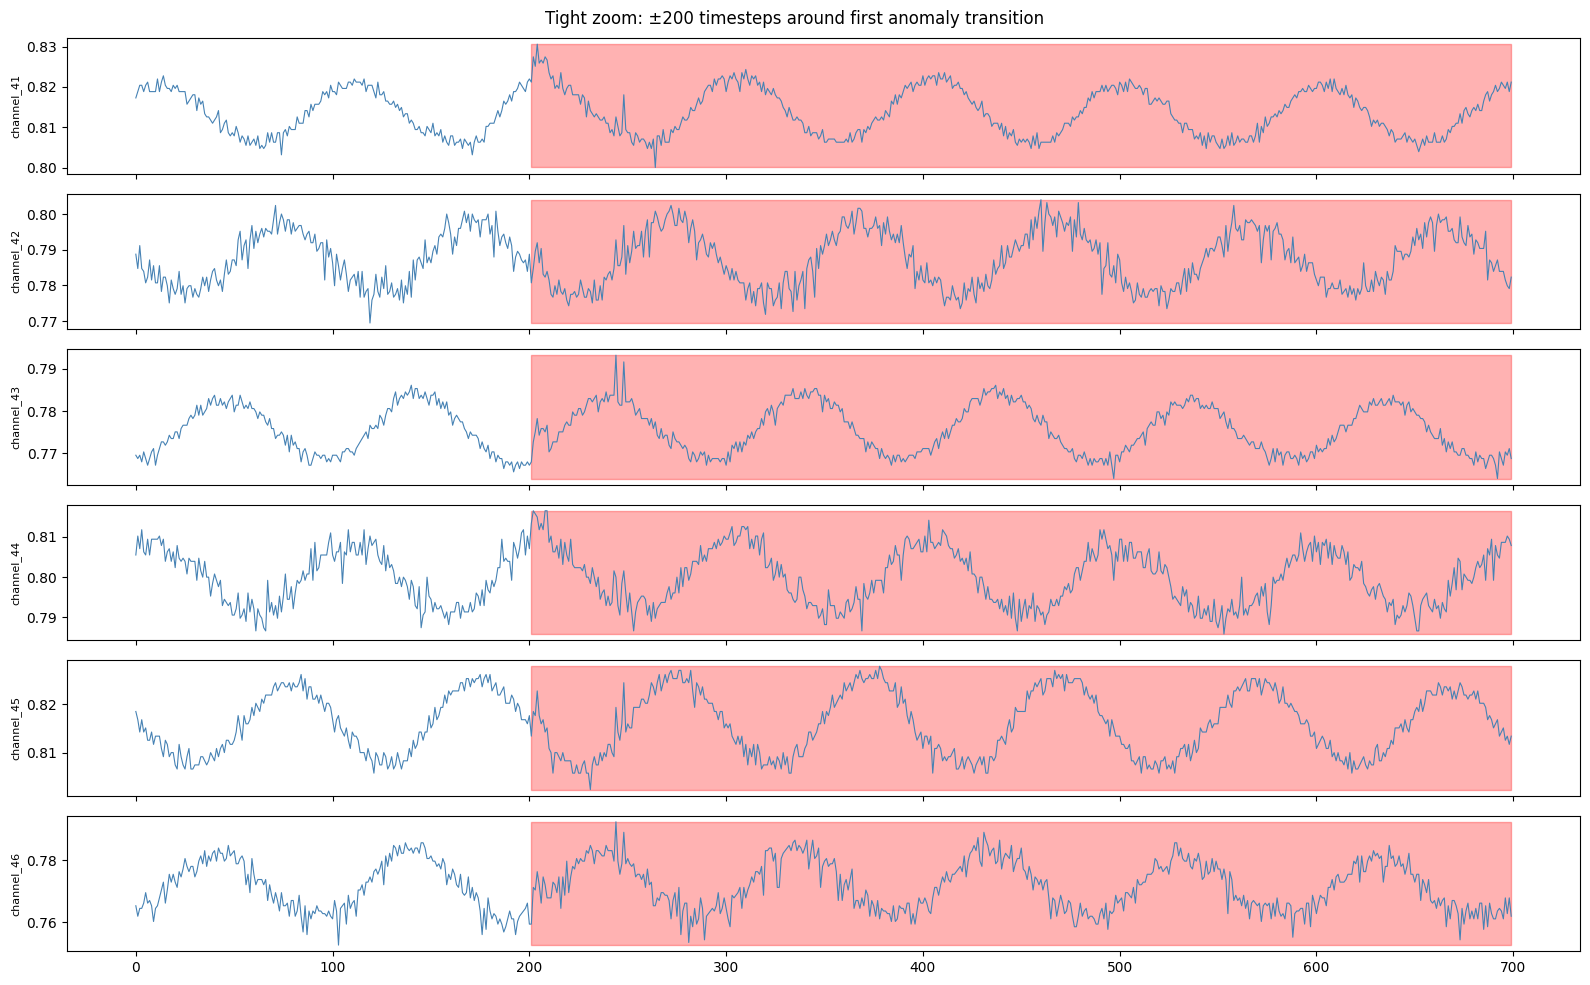

In [8]:
CHANNELS = [f"channel_{i}" for i in range(41, 47)]

# 1. What fraction of anomaly timesteps have extreme values?
anomaly_df = train[train["is_anomaly"] == 1][CHANNELS]
normal_df  = train[train["is_anomaly"] == 0][CHANNELS]

print("=== Fraction of timesteps with values < 0.01 (near zero / clipped) ===")
print(f"Normal  : {(normal_df < 0.01).any(axis=1).mean()*100:.4f}%")
print(f"Anomaly : {(anomaly_df < 0.01).any(axis=1).mean()*100:.4f}%")

print("\n=== Fraction of timesteps with values > 0.95 (near max / clipped) ===")
print(f"Normal  : {(normal_df > 0.95).any(axis=1).mean()*100:.4f}%")
print(f"Anomaly : {(anomaly_df > 0.95).any(axis=1).mean()*100:.4f}%")

# 2. Plot a histogram of values — normal vs anomaly
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, (ax, ch) in enumerate(zip(axes.flat, CHANNELS)):
    ax.hist(normal_df[ch].values,  bins=100, alpha=0.5, density=True,
            color="steelblue", label="normal")
    ax.hist(anomaly_df[ch].values, bins=100, alpha=0.5, density=True,
            color="tomato",    label="anomaly")
    ax.set_title(ch, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Value distributions: normal vs anomaly")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/eda_value_histograms.png", dpi=150)
plt.show()

# 3. Zoom into a SHORT window straddling an anomaly boundary
# Find where anomaly STARTS (first transition 0→1)
is_anom = train["is_anomaly"].values
transitions = np.where(np.diff(is_anom) == 1)[0]  # 0→1 transitions
print(f"\nNumber of anomaly events (0→1 transitions): {len(transitions)}")
print(f"First 10 transition points: {transitions[:10]}")

# Zoom into the first transition, ±200 timesteps
t0 = transitions[0]
window = slice(t0 - 200, t0 + 500)
fig, axes = plt.subplots(6, 1, figsize=(16, 10), sharex=True)
for ax, ch in zip(axes, CHANNELS):
    ax.plot(train[ch].values[window], lw=0.8, color="steelblue")
    ax.fill_between(range(700), train[ch].values[window].min(),
                                train[ch].values[window].max(),
                    where=(is_anom[window] == 1),
                    alpha=0.3, color="red")
    ax.set_ylabel(ch, fontsize=8)
plt.suptitle("Tight zoom: ±200 timesteps around first anomaly transition")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/eda_tight_zoom.png", dpi=150)
plt.show()

In [9]:
CHANNELS = [f"channel_{i}" for i in range(41, 47)]
is_anom = train["is_anomaly"].values

# 1. How many anomaly events are there, and how long are they?
transitions_start = np.where(np.diff(is_anom) == 1)[0]
transitions_end   = np.where(np.diff(is_anom) == -1)[0]
print(f"Number of anomaly events : {len(transitions_start)}")
if len(transitions_end) >= len(transitions_start):
    durations = transitions_end[:len(transitions_start)] - transitions_start
    print(f"Duration — mean: {durations.mean():.0f}  "
          f"min: {durations.min()}  max: {durations.max()}  "
          f"median: {np.median(durations):.0f}")

# 2. Try short-window rolling std
for w in [5, 10, 20, 50, 100]:
    scores = train[CHANNELS].rolling(w, center=True, min_periods=1).std().mean(axis=1).values
    normal_scores  = scores[is_anom == 0]
    anomaly_scores = scores[is_anom == 1]
    # separation = how well do the two distributions separate?
    # simple metric: (anomaly_mean - normal_mean) / normal_std
    sep = (anomaly_scores.mean() - normal_scores.mean()) / normal_scores.std()
    print(f"Window={w:>4}  normal_mean={normal_scores.mean():.5f}  "
          f"anomaly_mean={anomaly_scores.mean():.5f}  "
          f"separation={sep:.2f}x")

# 3. Try rolling std on pair DIFFERENCES
pairs = [("channel_41","channel_44"),
         ("channel_42","channel_45"),
         ("channel_43","channel_46")]
print("\nPair difference rolling std separation:")
for w in [5, 10, 20]:
    pair_scores = np.zeros(len(train))
    for c1, c2 in pairs:
        diff = (train[c1] - train[c2]).rolling(w, center=True, min_periods=1).std().values
        pair_scores += diff
    pair_scores /= 3
    sep = (pair_scores[is_anom==1].mean() - pair_scores[is_anom==0].mean()) / pair_scores[is_anom==0].std()
    print(f"  Window={w}  separation={sep:.2f}x")

Number of anomaly events : 190
Window=   5  normal_mean=0.00189  anomaly_mean=0.00209  separation=0.40x
Window=  10  normal_mean=0.00215  anomaly_mean=0.00259  separation=0.97x
Window=  20  normal_mean=0.00273  anomaly_mean=0.00345  separation=1.50x
Window=  50  normal_mean=0.00453  anomaly_mean=0.00552  separation=1.24x
Window= 100  normal_mean=0.00568  anomaly_mean=0.00685  separation=1.05x

Pair difference rolling std separation:
  Window=5  separation=-0.11x
  Window=10  separation=-0.07x
  Window=20  separation=-0.02x


In [10]:
from scipy.signal import periodogram

# Find dominant frequency in normal data
normal_data = train[train["is_anomaly"] == 0]["channel_41"].values[:50_000]

freqs, power = periodogram(normal_data, fs=1.0)
dominant_freq = freqs[np.argmax(power[1:]) + 1]  # skip DC component
period = int(1 / dominant_freq)

print(f"Dominant frequency : {dominant_freq:.5f} cycles/timestep")
print(f"Oscillation period : {period} timesteps")
print(f"Recommended window : {period * 2} timesteps (2 full cycles)")

Dominant frequency : 0.01018 cycles/timestep
Oscillation period : 98 timesteps
Recommended window : 196 timesteps (2 full cycles)


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.ndimage import binary_closing
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Dropout

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "/Users/alex/Downloads/esa-adb-challenge (1)"
CHANNELS = [f"channel_{i}" for i in range(41, 47)]

# ── FAST BASELINE CONFIG ──────────────────────────────────────────────────────
WINDOW_SIZE   = 98     # 1 cycle (not 2 — faster, still meaningful)
STEP_TRAIN    = 98     # non-overlapping windows — massive speedup, ~13k windows
STEP_TEST     = 49     # score every half-cycle on test
LSTM_UNITS    = 32     # smaller model — faster
BATCH_SIZE    = 512
EPOCHS        = 5      # just enough to get a baseline score
MIN_EVENT_LEN = 50
CLOSE_GAP     = 20

# ── LOAD ──────────────────────────────────────────────────────────────────────
train = pd.read_parquet(f"{DATA_DIR}/train.parquet")
test  = pd.read_parquet(f"{DATA_DIR}/test.parquet")

# ── PREPROCESS ────────────────────────────────────────────────────────────────
normal_mask   = train["is_anomaly"].values == 0
normal_vals   = train[CHANNELS].values[normal_mask].astype(np.float32)
test_vals     = test[CHANNELS].values.astype(np.float32)

scaler        = StandardScaler()
normal_scaled = scaler.fit_transform(normal_vals).astype(np.float32)
test_scaled   = scaler.transform(test_vals).astype(np.float32)

# ── WINDOWING ─────────────────────────────────────────────────────────────────
def make_windows(data, window_size, step):
    starts = range(0, len(data) - window_size + 1, step)
    return np.stack([data[i : i + window_size] for i in starts]).astype(np.float32)

X_train = make_windows(normal_scaled, WINDOW_SIZE, STEP_TRAIN)
X_test  = make_windows(test_scaled,   WINDOW_SIZE, STEP_TEST)
print(f"Train windows: {X_train.shape}  |  Test windows: {X_test.shape}")

# ── MODEL ─────────────────────────────────────────────────────────────────────
inp = Input(shape=(WINDOW_SIZE, len(CHANNELS)))
x   = LSTM(LSTM_UNITS, activation="tanh", return_sequences=False)(inp)
x   = Dropout(0.2)(x)
x   = RepeatVector(WINDOW_SIZE)(x)
x   = LSTM(LSTM_UNITS, activation="tanh", return_sequences=True)(x)
x   = Dropout(0.2)(x)
out = TimeDistributed(Dense(len(CHANNELS)))(x)

model = Model(inp, out)
model.compile(optimizer="adam", loss="mae")
model.summary()

# ── TRAIN ─────────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)

# ── SCORE ─────────────────────────────────────────────────────────────────────
normal_errors = np.mean(np.abs(X_train - model.predict(X_train, batch_size=512, verbose=0)), axis=(1,2))

test_recon    = model.predict(X_test, batch_size=512, verbose=1)
test_errors   = np.mean(np.abs(X_test - test_recon), axis=(1,2))

timestep_scores = np.zeros(len(test_scaled), dtype=np.float32)
for i, err in enumerate(test_errors):
    start = i * STEP_TEST
    end   = min(start + WINDOW_SIZE, len(timestep_scores))
    timestep_scores[start:end] = np.maximum(timestep_scores[start:end], err)

print(f"\nNormal errors — mean: {normal_errors.mean():.5f}  std: {normal_errors.std():.5f}")
print(f"Test scores   — mean: {timestep_scores.mean():.5f}  max: {timestep_scores.max():.5f}")

# ── SUBMIT ────────────────────────────────────────────────────────────────────
def remove_short_events(labels, min_len):
    result = labels.copy()
    i = 0
    while i < len(result):
        if result[i] == 1:
            j = i
            while j < len(result) and result[j] == 1:
                j += 1
            if (j - i) < min_len:
                result[i:j] = 0
            i = j
        else:
            i += 1
    return result

for pct in [95, 97, 99]:
    thresh = np.percentile(normal_errors, pct)
    raw    = (timestep_scores > thresh).astype(int)
    closed = binary_closing(raw, structure=np.ones(CLOSE_GAP)).astype(int)
    preds  = remove_short_events(closed, MIN_EVENT_LEN)
    rate   = preds.mean() * 100
    print(f"pct{pct} thresh={thresh:.5f} → {preds.sum():,} anomalies ({rate:.2f}%)")

    sub = pd.DataFrame({
        "id":           test["id"].values if "id" in test.columns else np.arange(len(test)),
        "anomaly_flag": preds.astype(int),
    })
    sub.to_parquet(f"{DATA_DIR}/submission_baseline_pct{pct}.parquet", index=False)

print("\nDone — upload submission_baseline_pct97.parquet to Kaggle first.")

2026-04-21 18:20:10.679834: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Train windows: (134532, 98, 6)  |  Test windows: (10637, 98, 6)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 98, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 98, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 98, 6)          │           198 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,510 (52.77 KB)

 Trainable params: 13,510 (52.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - loss: 0.5219 - val_loss: 0.3045
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - loss: 0.3410 - val_loss: 0.2869
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - loss: 0.3232 - val_loss: 0.2735
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 201s 847ms/step - loss: 0.3153 - val_loss: 0.2709
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 200s 843ms/step - loss: 0.3105 - val_loss: 0.2695
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step

Normal errors — mean: 0.26932  std: 0.02548
Test scores   — mean: 0.27756  max: 0.70786
pct95 thresh=0.31931 → 34,545 anomalies (6.63%)
pct97 thresh=0.33424 → 26,705 anomalies (5.12%)
pct99 thresh=0.35581 → 18,473 anomalies (3.54%)

Done — upload submission_baseline_pct97.parquet to Kaggle first.
